# **Predicción de la demanda horaria de bicicletas compartidas**

**Fase 1 - Modelo predictivo**

Proyecto Integrador - Modelos y Simulación de Sistemas I

## **Integrantes**
- Santiago Jiménez Escobar
- Santiago Durán Carmona

## **Contenido del notebook**
1. Introducción y descripción del conjunto de datos
2. Auditoría inicial y análisis exploratorio (EDA)
3. Inyección controlada de valores faltantes (MCAR)
4. Selección de variables, partición train/test y preprocesamiento con `Pipeline`
5. Modelo base (Ridge) y modelo predictivo (Random Forest)
6. Evaluación, análisis de sensibilidad y validaciones adicionales
7. Almacenamiento del modelo y conclusiones

# **Introducción**
- **Descripción del problema seleccionado:**  
  Desarrollar un modelo de Machine Learning capaz de predecir la demanda horaria de un sistema de bicicletas compartidas, utilizando variables temporales, de calendario y meteorológicas. El problema se basa en los datos históricos del sistema Capital Bikeshare de Washington D. C., con 17.379 registros horarios correspondientes a los años 2011 y 2012.

- **Definición del objetivo del modelo:**  
  Desarrollar un modelo de Machine Learning capaz de predecir la cantidad de bicicletas que serán alquiladas durante una determinada hora, a partir de variables temporales, de calendario y meteorológicas.

- **Tipo de problema (clasificación / regresión):**  
  **Regresión**, debido a que el modelo debe predecir un valor numérico continuo correspondiente a la cantidad de alquileres de bicicletas durante una hora determinada.

- **Identificación de la variable objetivo:**  
  La variable objetivo es **`cnt`**, que representa el número total de alquileres de bicicletas realizados durante cada hora. Esta variable corresponde a la suma de los usuarios casuales (`casual`) y registrados (`registered`).

- **Fuente de los datos:**  
  El conjunto de datos utilizado corresponde al histórico del sistema **Capital Bikeshare** y fue obtenido desde Kaggle:  
  https://www.kaggle.com/datasets/amil09/bike-sharing-dataset/data?select=Bike+Share+hourly.csv

# **Imports y configuración global**

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Modelado
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configuración de gráficas
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

BASE_DIR = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw").is_dir()),
    Path.cwd().parent.parent,
)
DATA_RAW = BASE_DIR / "data" / "raw" / "bike_share_hourly.csv"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "fase-1" / "models"
REPORTS_DIR = BASE_DIR / "fase-1" / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

for d in [DATA_PROCESSED, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# **Carga del dataset**

In [2]:
df = pd.read_csv(DATA_RAW)

print(f"Shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")
df.head()

Shape: (17379, 17)
Columnas: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


# **Descripción del conjunto de datos**

**Número de observaciones y de variables:** el conjunto de datos contiene **17.379 observaciones** (una por hora) y **17 variables**, como se muestra en la salida de la celda anterior.

**Significado de la variable objetivo:** Para este proyecto la variable objetivo es llamada "cnt", el conteo total de alquileres por hora, resultado de sumar los usuarios casuales (casual) y los registrados (registered). Precisamente por ser una suma exacta de estas dos columnas, casual y registered se excluirán como variables predictoras: usarlas equivaldría a filtrar información directa del resultado, lo cual invalidaría cualquier métrica de desempeño obtenida.

**Tipos de variables:** En el análisis inicial del conjunto de datos, al cargarlo correctamente con `pd.read_csv`, Pandas infiere los tipos de forma automática. La mayoría de las variables quedan como `int64` (`season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`, `casual`, `registered` y la variable objetivo `cnt`), mientras que `temp`, `atemp`, `hum` y `windspeed` quedan como `float64`, ya que corresponden a variables continuas normalizadas entre 0 y 1. La única columna que requiere un tratamiento adicional es `dteday`, que se carga como texto (`object` o `str`, según la versión de pandas) al representar una fecha; sin embargo, no es necesario convertirla a `datetime` porque sus componentes (año, mes, día de la semana, hora) ya están disponibles en columnas separadas (`yr`, `mnth`, `weekday`, `hr`). Es importante notar que, aunque variables como `season`, `weathersit`, `mnth`, `hr` y `weekday` están codificadas numéricamente, en realidad son categóricas y deberán tratarse como tal (por ejemplo, mediante one-hot encoding) antes de entrenar el modelo, en lugar de tratarse como cantidades continuas.

In [3]:
for columna in df.columns:
    print(columna, "->", df[columna].dtype)

instant -> int64
dteday -> str
season -> int64
yr -> int64
mnth -> int64
hr -> int64
holiday -> int64
weekday -> int64
workingday -> int64
weathersit -> int64
temp -> float64
atemp -> float64
hum -> float64
windspeed -> float64
casual -> int64
registered -> int64
cnt -> int64


**Posibles limitaciones del dataset:** El dataset puede presentar algunas limitaciones, como la necesidad de convertir correctamente los tipos de datos, posibles valores faltantes o inconsistencias y la representación limitada de factores externos que pueden afectar la demanda de bicicletas, como eventos especiales, condiciones económicas o cambios en los hábitos de los usuarios. Además, los datos corresponden a un período específico, por lo que los patrones identificados podrían no representar completamente el comportamiento en otros períodos o contextos.

# **Auditoría inicial: nulos, tipos, duplicados**

In [4]:
print("=== Nulos por columna (dataset original) ===")
print(df.isnull().sum())

print("\n=== Tipos de datos ===")
print(df.dtypes)

print(f"\n=== Filas duplicadas: {df.duplicated().sum()} ===")
print(f"=== Registros totales: {len(df)} ===")

=== Nulos por columna (dataset original) ===
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== Tipos de datos ===
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== Filas duplicadas: 0 ===
=== Registros totales: 17379 ===


**Identificación y cuantificación de valores faltantes por variable:** el conjunto de datos original no tiene valores faltantes en ninguna columna. Por este motivo, más adelante se inyectan valores faltantes de forma controlada (mecanismo MCAR) para poder aplicar y justificar una estrategia de imputación dentro del pipeline de preprocesamiento.

# **Exploración de los datos**

## **Estadísticas descriptivas**

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


El resultado muestra que el dataset contiene 17.379 registros y 17 variables, sin datos faltantes en ninguna columna. Además, se observa que algunas variables son categóricas y presentan un número limitado de valores únicos, como season con 4 y mnth con 12, mientras que variables como instant tienen valores únicos para cada registro. La columna workingday presenta como valor más frecuente 1, con 11.865 registros, y holiday tiene como valor más frecuente 0, con 16.879 registros, lo que indica que la mayoría de los registros corresponden a días laborales y no festivos.

## **Distribución de la variable objetivo (cnt)**

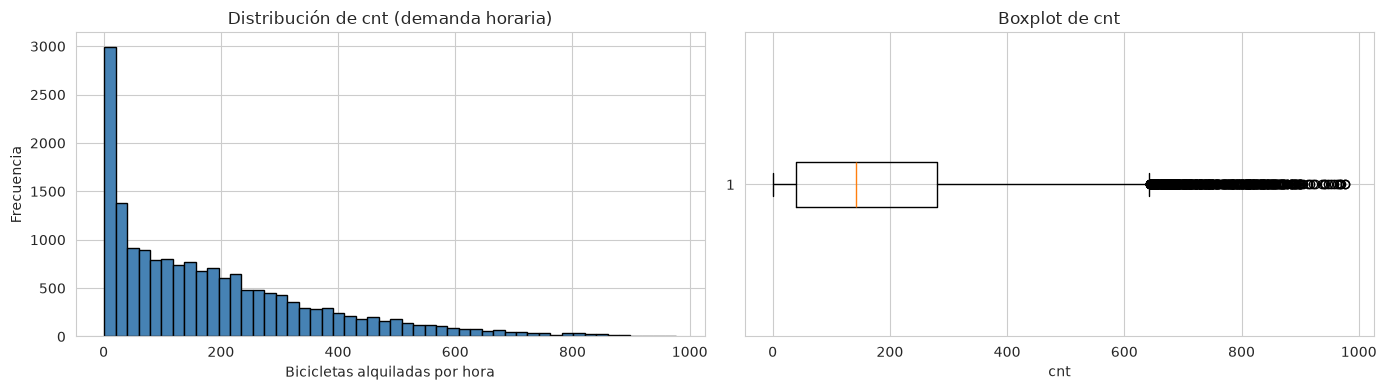

Asimetría (skew): 1.277
Curtosis: 1.417


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["cnt"], bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Distribución de cnt (demanda horaria)")
axes[0].set_xlabel("Bicicletas alquiladas por hora")
axes[0].set_ylabel("Frecuencia")

axes[1].boxplot(df["cnt"], orientation="horizontal")
axes[1].set_title("Boxplot de cnt")
axes[1].set_xlabel("cnt")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_distribucion_cnt.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Asimetría (skew): {df['cnt'].skew():.3f}")
print(f"Curtosis: {df['cnt'].kurtosis():.3f}")

La gráfica muestra que la variable objetivo cnt presenta una distribución asimétrica hacia la derecha, ya que la mayor concentración de registros se encuentra en valores bajos de alquileres y la frecuencia disminuye progresivamente a medida que aumenta la cantidad de alquileres. También se observan algunos valores altos con menor frecuencia, lo que puede indicar la presencia de valores extremos en el dataset.

## **Análisis de relaciones entre variables predictoras y la variable objetivo**

Inicialmente se realiza el análisis sin ningún tratamiento de los datos, y se analizan las que se consideran variables numéricas, que son temp, atemp, hum y windspeed. Como resultado de los graficos se observa que la variable temp tiene una relación positiva con la variable objetivo cnt, es decir, a medida que aumenta la temperatura, también aumenta la cantidad de alquileres, aunque con una disminución en la zona media de la temperatura. Por otro lado, las variables atemp, hum y windspeed presentan una relación negativa con la variable objetivo cnt hacia la derecha, lo que indica que a medida que aumentan estas variables, disminuye la cantidad de alquileres.

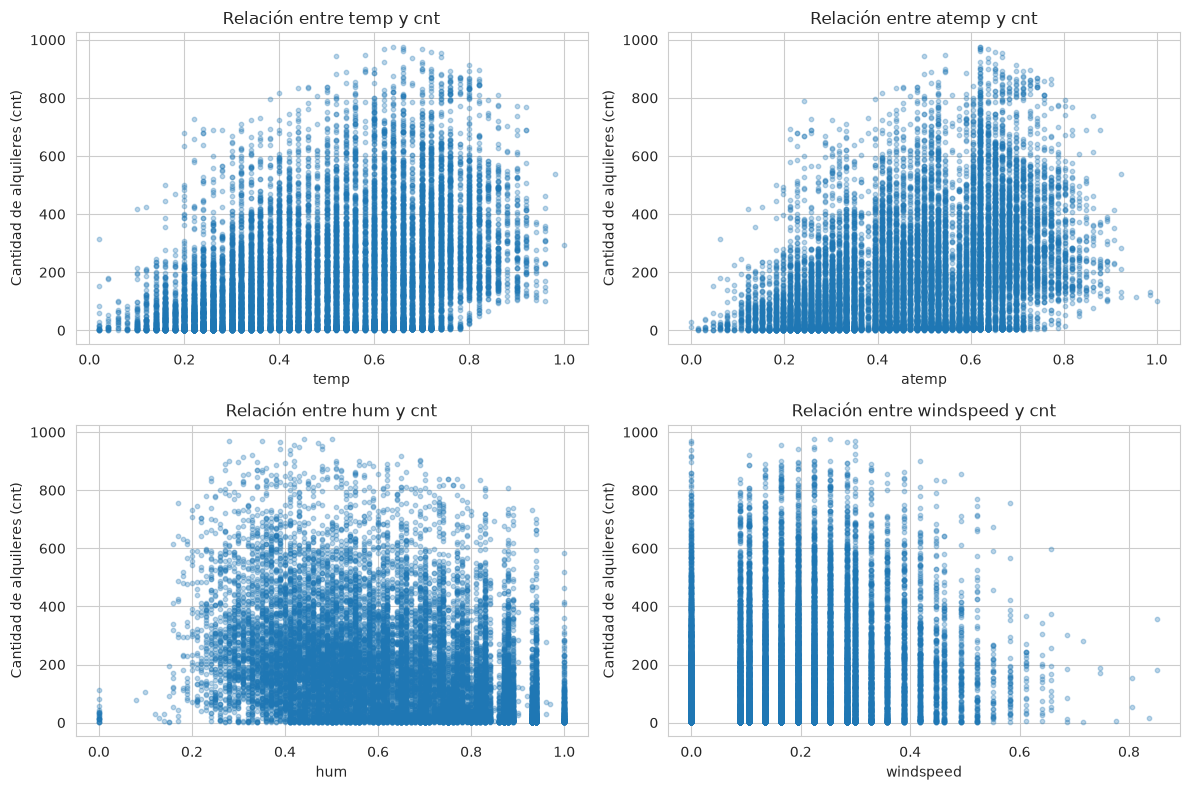

In [7]:
variables_numericas = ["temp", "atemp", "hum", "windspeed"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, variable in zip(axes.flatten(), variables_numericas):
    ax.scatter(df[variable], df["cnt"], alpha=0.3, s=10)
    ax.set_xlabel(variable)
    ax.set_ylabel("Cantidad de alquileres (cnt)")
    ax.set_title(f"Relación entre {variable} y cnt")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_relaciones_vs_cnt.png", dpi=100, bbox_inches="tight")
plt.show()

## **Análisis de correlación entre variables numéricas**

                temp     atemp       hum  windspeed    casual  registered  \
temp        1.000000  0.987672 -0.069881  -0.023125  0.459616    0.335361   
atemp       0.987672  1.000000 -0.051918  -0.062336  0.454080    0.332559   
hum        -0.069881 -0.051918  1.000000  -0.290105 -0.347028   -0.273933   
windspeed  -0.023125 -0.062336 -0.290105   1.000000  0.090287    0.082321   
casual      0.459616  0.454080 -0.347028   0.090287  1.000000    0.506618   
registered  0.335361  0.332559 -0.273933   0.082321  0.506618    1.000000   
cnt         0.404772  0.400929 -0.322911   0.093234  0.694564    0.972151   

                 cnt  
temp        0.404772  
atemp       0.400929  
hum        -0.322911  
windspeed   0.093234  
casual      0.694564  
registered  0.972151  
cnt         1.000000  


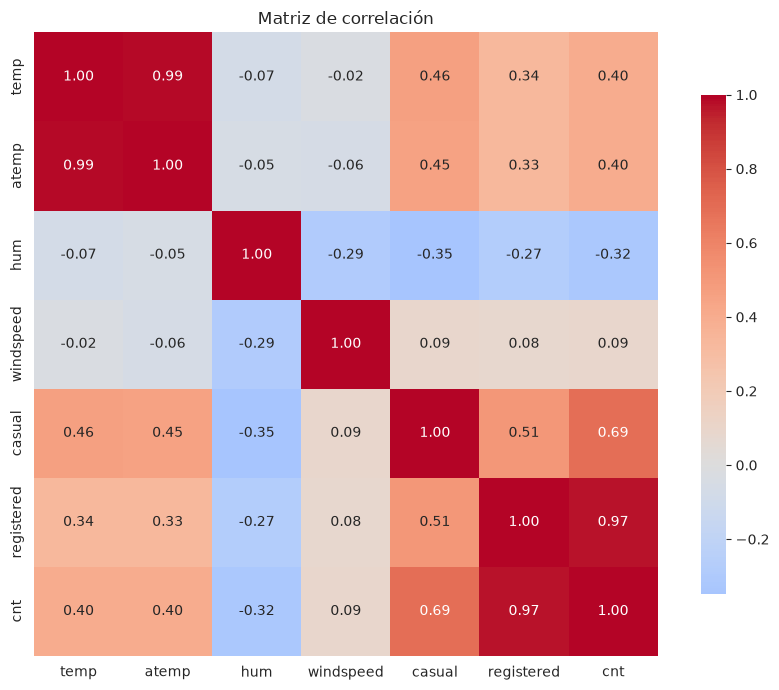

In [8]:
# Matriz de correlación de variables numéricas

# Seleccionar variables numéricas
num_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]

# Calcular matriz de correlación
corr = df[num_cols].corr()

print(corr)

# Graficar mapa de calor
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})

plt.title("Matriz de correlación")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_correlaciones.png", dpi=100, bbox_inches="tight")
plt.show()

En el gráfico destacan asociaciones fuertemente positivas en tonos rojos oscuros, principalmente casi perfectas entre la temperatura real y la sensación térmica ($0.99$), así como entre los usuarios registrados y el total de alquileres ($0.97$). Por otro lado, las variables ambientales como la humedad y el viento muestran correlaciones débiles o negativas respecto al uso del servicio, representadas en tonos azules.

## **Patrones temporales**

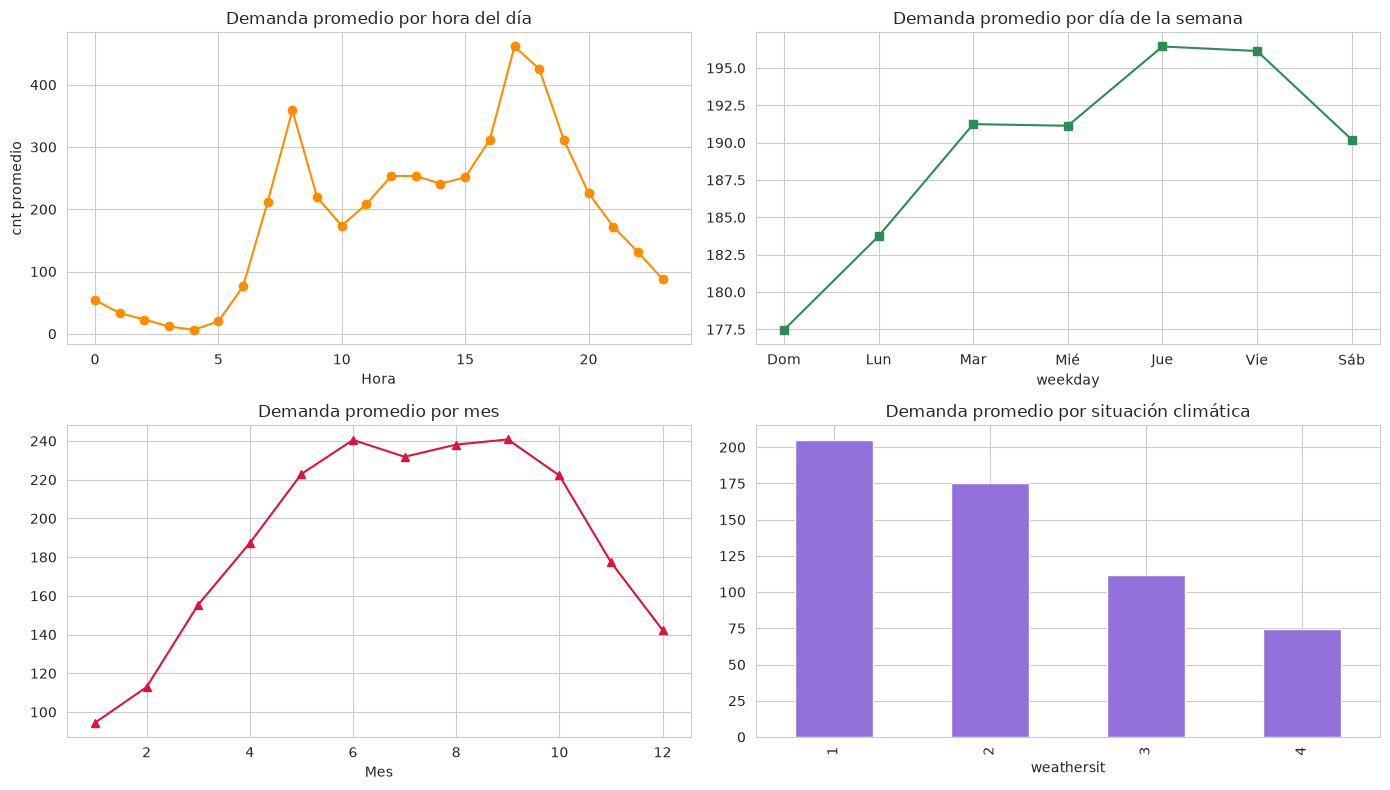

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Por hora
df.groupby("hr")["cnt"].mean().plot(ax=axes[0, 0], marker="o", color="darkorange")
axes[0, 0].set_title("Demanda promedio por hora del día")
axes[0, 0].set_xlabel("Hora")
axes[0, 0].set_ylabel("cnt promedio")

# Por día de la semana
dias = ["Dom", "Lun", "Mar", "Mié", "Jue", "Vie", "Sáb"]
df.groupby("weekday")["cnt"].mean().plot(ax=axes[0, 1], marker="s", color="seagreen")
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(dias)
axes[0, 1].set_title("Demanda promedio por día de la semana")

# Por mes
df.groupby("mnth")["cnt"].mean().plot(ax=axes[1, 0], marker="^", color="crimson")
axes[1, 0].set_title("Demanda promedio por mes")
axes[1, 0].set_xlabel("Mes")

# Por clima
df.groupby("weathersit")["cnt"].mean().plot(kind="bar", ax=axes[1, 1], color="mediumpurple")
axes[1, 1].set_title("Demanda promedio por situación climática")
axes[1, 1].set_xlabel("weathersit")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_patrones_temporales.png", dpi=100, bbox_inches="tight")
plt.show()

La demanda por hora tiene dos picos claros, alrededor de las 8:00 (≈359 alquileres promedio) y entre las 17:00 y las 18:00 (≈461 y ≈426), que coinciden con los desplazamientos hacia y desde el trabajo; la madrugada es el momento de menor uso (≈6 alquileres a las 4:00). Por día de la semana la demanda es bastante estable (de ≈177 el domingo a ≈196 el jueves y el viernes), y por mes aumenta de forma marcada en los meses cálidos (≈240 en junio y septiembre) frente al invierno (≈94 en enero). Finalmente, la demanda cae a medida que empeora el clima: ≈205 con cielo despejado, ≈175 con nubes o niebla y ≈112 con lluvia o nieve ligera; la categoría 4 (lluvia o nieve fuerte) solo tiene 3 registros, por lo que sus resultados no son representativos. Estos patrones justifican tratar `hr`, `mnth`, `weekday` y `weathersit` como variables categóricas en el modelo.

## **Visualizaciones relevantes y útiles**

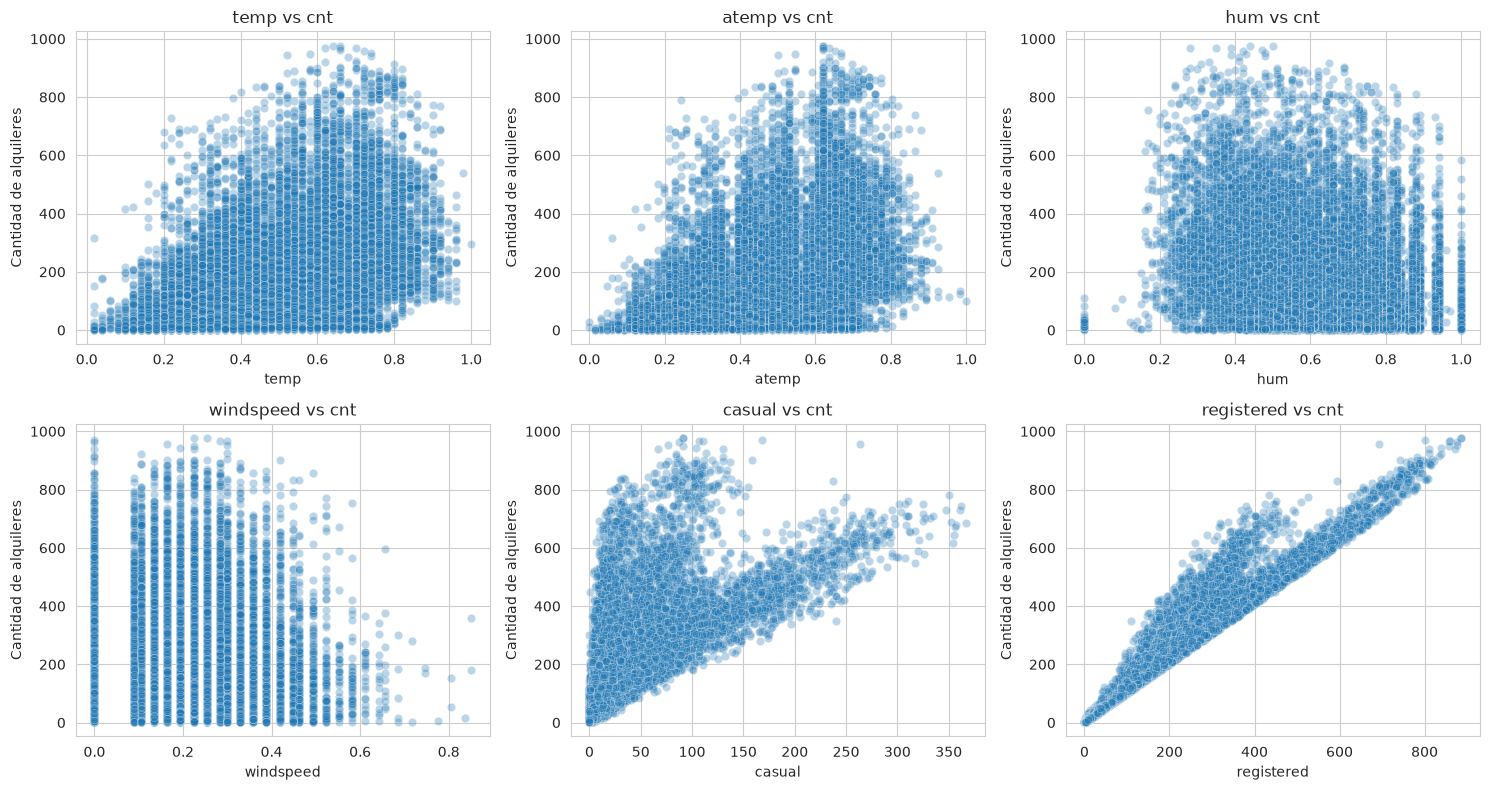

In [10]:
variables = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, variable in zip(axes.flatten(), variables):
    sns.scatterplot(
        data=df,
        x=variable,
        y='cnt',
        alpha=0.3,
        ax=ax
    )
    
    ax.set_title(f'{variable} vs cnt')
    ax.set_xlabel(variable)
    ax.set_ylabel('Cantidad de alquileres')

plt.tight_layout()
plt.show()

# **Inyección controlada de valores (MCAR)**

El dataset original no contiene nulos. La guía exige que al menos una variable predictora tenga entre 0.1% y 2% de valores faltantes. Se inyectan nulos de forma MCAR (Missing Completely At Random) con semilla fija, sobre las dos variables que físicamente dependen de sensores ambientales: **hum** (humedad) y **windspeed** (velocidad del viento). Esto simula fallos de sensores reales y permite demostrar técnicas de imputación. Se deja registro exacto para asegurar reproducibilidad.

In [11]:
PORC_NULOS_HUM = 0.012       # 1.2 %
PORC_NULOS_WIND = 0.017      # 1.7 %

rng = np.random.default_rng(RANDOM_STATE)
n = len(df)

# Índices aleatorios sin reemplazo
idx_hum = rng.choice(n, size=int(n * PORC_NULOS_HUM), replace=False)
idx_wind = rng.choice(n, size=int(n * PORC_NULOS_WIND), replace=False)

df.loc[idx_hum, "hum"] = np.nan
df.loc[idx_wind, "windspeed"] = np.nan

print("=== Nulos tras inyección MCAR ===")
print(df[["hum", "windspeed"]].isnull().sum())
print(f"Porcentaje real hum: {df['hum'].isnull().mean()*100:.2f}%")
print(f"Porcentaje real windspeed: {df['windspeed'].isnull().mean()*100:.2f}%")

=== Nulos tras inyección MCAR ===
hum          208
windspeed    295
dtype: int64
Porcentaje real hum: 1.20%
Porcentaje real windspeed: 1.70%


In [12]:
# Verificación de la inyección: porcentajes esperados y variables críticas intactas
assert abs(df["hum"].isnull().mean() - PORC_NULOS_HUM) < 0.001
assert abs(df["windspeed"].isnull().mean() - PORC_NULOS_WIND) < 0.001
assert df["cnt"].isnull().sum() == 0   # el target no se toca
assert df["hr"].isnull().sum() == 0    # las variables críticas no se tocan
print("Inyección MCAR validada")

Inyección MCAR validada


In [13]:
# Guardar dataset con nulos inyectados
processed_path = DATA_PROCESSED / "bike_share_with_nans.csv"
df.to_csv(processed_path, index=False)
print(f"Dataset procesado guardado en: {processed_path}")

Dataset procesado guardado en: /home/santiago/GitHub/modelos1-price-prediction/data/processed/bike_share_with_nans.csv


# **Selección de variables y fuga de información**

Después de revisar las correlaciones entre las variables numéricas para identificar posibles problemas de redundancia y fuga de información, se decidió excluir las siguientes columnas del conjunto de variables predictoras:

Columnas excluidas y el por qué:

- **instant**    : índice, sin poder predictivo.
- **dteday**     : fecha cruda; ya tenemos yr, mnth, weekday, etc.
- **casual**     : componente de cnt → FUGA (cnt = casual + registered).
- **registered** : componente de cnt → FUGA (cnt = casual + registered).
- **atemp**      : colineal con temp (r≈0.99); dado que existe una alta relación esperada entre ambas, se conserva únicamente temp para reducir la redundancia.
- **cnt**         : es la variable objetivo (TARGET); se excluye como predictora para no filtrar el resultado que se busca predecir.

In [14]:
TARGET = "cnt"
COLS_EXCLUIDAS = ["instant", "dteday", "casual", "registered", "atemp", TARGET]

feature_cols = [c for c in df.columns if c not in COLS_EXCLUIDAS]
print(f"Variables predictoras ({len(feature_cols)}): {feature_cols}")

X = df[feature_cols].copy()
y = df[TARGET].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Variables predictoras (11): ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed']

X shape: (17379, 11)
y shape: (17379,)


# **Partición train/test**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True   # explícito: NO es serie de tiempo
)

print(f"Train: {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test : {X_test.shape}   ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nNulos en train (hum, windspeed):")
print(X_train[["hum", "windspeed"]].isnull().sum())
print(f"Nulos en test (hum, windspeed):")
print(X_test[["hum", "windspeed"]].isnull().sum())

Train: (13903, 11)  (80%)
Test : (3476, 11)   (20%)

Nulos en train (hum, windspeed):
hum          166
windspeed    241
dtype: int64
Nulos en test (hum, windspeed):
hum          42
windspeed    54
dtype: int64


Se utilizó una partición aleatoria (hold-out) del 80% para entrenamiento y 20% para prueba, sin estratificación temporal, ya que el problema no se trata como una serie de tiempo sino como una predicción puntual por hora a partir de variables temporales y meteorológicas explícitas (`hr`, `mnth`, `weekday`, etc.). Los registros de `hum` y `windspeed` con valores faltantes se distribuyeron proporcionalmente entre ambos conjuntos (166/42 y 241/54 respectivamente), lo cual es consistente con el 80/20 esperado y confirma que la inyección MCAR no introdujo sesgo en la partición.

**Grupos naturales y posible fuga:** cada día del calendario aparece hasta 24 veces (una fila por hora), por lo que una partición aleatoria puede dejar horas del mismo día en ambos conjuntos. Se aceptó esta decisión porque el objetivo es predecir la demanda de una hora a partir de sus propias condiciones (hora, calendario y clima) y no a partir de la demanda de horas vecinas, que no se usa como predictora. Aun así, esto puede hacer que las métricas de prueba resulten algo optimistas frente a días completamente nuevos, y se deja como mejora futura una validación agrupada por día.

# **Pipelines de preprocesamiento**

Se construyó un pipeline de preprocesamiento con ColumnTransformer: las variables numéricas (temp, hum, windspeed) se imputan con la mediana (robusta ante los valores extremos vistos en el EDA) y se escalan con StandardScaler; las variables categóricas y discretas (season, weathersit, mnth, hr, weekday, yr, holiday, workingday) se codifican con one-hot en vez de dejarlas como enteros, para evitar que el modelo asuma un orden que no existe por ejemplo, que weathersit=3 sea el triple de weathersit=1. Al ir todo dentro de un Pipeline, el ajuste de estas transformaciones (mediana, media, categorías vistas) se hace únicamente con los datos de entrenamiento cuando se llame a .fit(), evitando fuga de información hacia el conjunto de prueba.

In [16]:
# Variables numéricas continuas -> imputar (mediana) + escalar
num_cols = ["temp", "hum", "windspeed"]

# Variables categóricas nominales -> one-hot
cat_cols = ["season", "weathersit"]

# Variables cíclicas/categóricas discretas -> one-hot (evita ordinalidad falsa)
# mnth, hr, weekday, holiday, workingday -> one-hot
# yr también se incluye en one-hot por simplicidad del pipeline, aunque al ser
# binaria (0/1) esto solo agrega una columna redundante, sin afectar el modelo
cyclic_cols = ["mnth", "hr", "weekday"]
binary_cols = ["yr", "holiday", "workingday"]

# Nota: season y weathersit también son categóricas nominales,
# se unen con cyclic_cols para simplificar
cat_all = cat_cols + cyclic_cols + binary_cols

# Pipeline numérico
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categórico
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combinador
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_all)
])

print("Preprocesador listo.")
print(f"  Numéricas: {num_cols}")
print(f"  Categóricas: {cat_all}")

Preprocesador listo.
  Numéricas: ['temp', 'hum', 'windspeed']
  Categóricas: ['season', 'weathersit', 'mnth', 'hr', 'weekday', 'yr', 'holiday', 'workingday']


**Decisiones adicionales de preparación:** (1) `dteday` no se convierte a fecha ni se usa como predictora, porque sus componentes ya están disponibles en `yr`, `mnth`, `weekday` y `hr`; (2) no se crearon variables derivadas, ya que el objetivo de esta fase es establecer un modelo con las variables originales; (3) no se eliminaron ni transformaron valores atípicos de `cnt`, porque corresponden a horas pico reales de demanda y no a errores de medición.

**Prevención de fuga de información:**
- La variable objetivo `cnt` no se usa como predictora, y `casual` y `registered` se excluyen porque su suma es exactamente `cnt`.
- El conjunto de prueba solo interviene para evaluar; nunca para entrenar ni para ajustar transformaciones.
- Imputación, escalamiento y codificación one-hot están dentro del `Pipeline`, por lo que se ajustan únicamente con los datos de entrenamiento al llamar a `.fit()`.
- Todas las variables predictoras (hora, calendario y clima) se conocen en el momento de la predicción; no se usa ninguna variable posterior al evento.
- Se analizó el riesgo de la partición aleatoria con horas del mismo día en ambos conjuntos (ver sección de partición).

# **Modelo base (Baseline)**

Como modelo base se utilizará Ridge Regression, un modelo de regresión lineal regularizado. Es apropiado como baseline porque la variable objetivo cnt es numérica y representa el número total de alquileres. Su función en esta etapa no es necesariamente obtener el mejor resultado, sino establecer una referencia que posteriormente permita evaluar si un modelo más complejo consigue mejorar el desempeño.

In [17]:
# ============================================================
# MODELO BASE - RIDGE REGRESSION
# ============================================================

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

# Entrenar el modelo base
baseline_model.fit(X_train, y_train)

# Realizar predicciones sobre el conjunto de prueba
y_pred_baseline = baseline_model.predict(X_test)

print("Modelo base entrenado correctamente.")

Modelo base entrenado correctamente.


# **Evaluar el modelo base**

Para evaluar el baseline se utilizan las métricas que ya tenemos importadas en el notebook: MAE, RMSE y R². El MAE representa el error absoluto promedio en número de alquileres, el RMSE da mayor importancia a los errores grandes y el R² permite observar qué proporción de la variabilidad de cnt consigue explicar el modelo.

In [18]:
# ============================================================
# EVALUACIÓN DEL MODELO BASE
# ============================================================

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print("=== RESULTADOS DEL MODELO BASE (RIDGE) ===")
print(f"MAE  : {mae_baseline:.2f}")
print(f"RMSE : {rmse_baseline:.2f}")
print(f"R²   : {r2_baseline:.4f}")

=== RESULTADOS DEL MODELO BASE (RIDGE) ===
MAE  : 74.06
RMSE : 100.49
R²   : 0.6811


# **Resultados del modelo base**

El modelo base seleccionado fue Ridge Regression. Después de realizar el entrenamiento sobre el conjunto destinado para este propósito, se realizaron predicciones sobre el conjunto de prueba. El modelo obtuvo un MAE de 74.06, un RMSE de 100.49 y un R² de 0.6811.

El MAE indica que, en promedio, las predicciones del modelo presentan un error de aproximadamente 74.06 alquileres respecto al valor real. El RMSE permite complementar esta interpretación teniendo en cuenta los errores de mayor magnitud, mientras que el R² permite observar la capacidad del modelo para explicar la variabilidad de la demanda.

# **Modelo predictivo**

### **Selección y justificación del algoritmo**

Para el modelo predictivo se seleccionó **Random Forest Regressor**, debido a que el problema planteado corresponde a una tarea de regresión en la que se busca predecir la cantidad total de alquileres representada por la variable `cnt`.

Random Forest permite construir múltiples árboles de decisión y combinar sus predicciones, lo que facilita la identificación de relaciones no lineales entre las variables predictoras y la demanda. Esta característica resulta relevante para el conjunto de datos utilizado, debido a la presencia de variables temporales, meteorológicas y categóricas que pueden interactuar entre sí.

El modelo será comparado posteriormente con Ridge Regression, utilizado como modelo base, con el propósito de determinar si una técnica de mayor complejidad consigue mejorar las métricas obtenidas por el baseline.

# **Entrenar el modelo**

In [19]:
# ============================================================
# MODELO PREDICTIVO - RANDOM FOREST
# ============================================================

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Entrenamiento
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

print("Random Forest entrenado correctamente.")

Random Forest entrenado correctamente.


# **Evaluar Random Forest**

In [20]:
# ============================================================
# EVALUACIÓN DE RANDOM FOREST
# ============================================================

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("=== RESULTADOS RANDOM FOREST ===")
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

=== RESULTADOS RANDOM FOREST ===
MAE  : 29.34
RMSE : 48.02
R²   : 0.9272


# **Comparar el modelo con el baseline**

In [21]:
# ============================================================
# COMPARACIÓN BASELINE VS RANDOM FOREST
# ============================================================

resultados = pd.DataFrame({
    "Modelo": [
        "Ridge - Baseline",
        "Random Forest"
    ],
    "MAE": [
        mae_baseline,
        mae_rf
    ],
    "RMSE": [
        rmse_baseline,
        rmse_rf
    ],
    "R2": [
        r2_baseline,
        r2_rf
    ]
})

print("=== COMPARACIÓN DE MODELOS ===")
display(resultados)

=== COMPARACIÓN DE MODELOS ===


,Modelo,MAE,RMSE,R2
0,Ridge - Baseline,74.057616,100.487324,0.681113
1,Random Forest,29.338987,48.017463,0.927186


# **Analizar si el modelo mejora al baseline**

In [22]:
# ============================================================
# ANÁLISIS DE MEJORA
# ============================================================

mejora_mae = ((mae_baseline - mae_rf) / mae_baseline) * 100
mejora_rmse = ((rmse_baseline - rmse_rf) / rmse_baseline) * 100
diferencia_r2 = r2_rf - r2_baseline

print("=== COMPARACIÓN DE DESEMPEÑO ===")
print(f"Cambio relativo en MAE : {mejora_mae:.2f}%")
print(f"Cambio relativo en RMSE: {mejora_rmse:.2f}%")
print(f"Diferencia en R²       : {diferencia_r2:.4f}")

if mae_rf < mae_baseline and rmse_rf < rmse_baseline and r2_rf > r2_baseline:
    print("\nRandom Forest presenta mejores resultados que el baseline.")
else:
    print("\nRandom Forest no mejora simultáneamente todas las métricas del baseline.")

=== COMPARACIÓN DE DESEMPEÑO ===
Cambio relativo en MAE : 60.38%
Cambio relativo en RMSE: 52.22%
Diferencia en R²       : 0.2461

Random Forest presenta mejores resultados que el baseline.


# **Comparación del modelo con el baseline**

Al comparar Ridge Regression, utilizado como modelo base, con Random Forest Regressor, se observa que el baseline obtuvo un MAE de 74.057616, un RMSE de 100.487324 y un R² de 0.681113, mientras que el modelo Random Forest obtuvo un MAE de 29.338987, un RMSE de 48.017463 y un R² de 0.927186.

De acuerdo con estas métricas, mejora el desempeño obtenido por el modelo base. Para determinarlo se consideran conjuntamente las tres métricas: una reducción del MAE y del RMSE representa una disminución del error, mientras que un aumento del R² representa una mayor capacidad para explicar la variabilidad de la variable objetivo.

# **¿La métrica obtenida es razonable?**

### **Análisis de las métricas**

Las métricas obtenidas se consideran razonables para el problema planteado, especialmente en el caso del modelo Random Forest. El modelo obtuvo un MAE de 29,34, lo que significa que sus predicciones presentan, en promedio, una diferencia aproximada de 29 alquileres respecto al valor real. Por otra parte, el RMSE de 48,02 indica que, aunque existen algunos errores de mayor magnitud, estos se mantienen en un nivel inferior al obtenido por el modelo base. Finalmente, el R² de 0,927 indica que el modelo consigue explicar aproximadamente el 92,7 % de la variabilidad observada en la cantidad de alquileres.

Al comparar estos resultados con el modelo Ridge utilizado como baseline, se observa una reducción importante del error, pasando de un MAE de 74,06 a 29,34 y de un RMSE de 100,49 a 48,02. Asimismo, el R² aumenta de 0,681 a 0,927. Por lo tanto, las métricas obtenidas por Random Forest muestran un desempeño superior al modelo base y resultan coherentes con el objetivo de predecir la demanda horaria de bicicletas.

# **Evaluación del modelo**

## **Justificación de la métrica seleccionada**

Se seleccionaron MAE, RMSE y R² debido a que el problema corresponde a una tarea de regresión en la que la variable objetivo cnt representa una cantidad numérica de alquileres por hora. El MAE permite interpretar el error promedio directamente en términos de cantidad de alquileres, facilitando la comprensión del desempeño del modelo. El RMSE permite identificar el impacto de errores de mayor magnitud, ya que penaliza con mayor intensidad las diferencias grandes entre los valores reales y las predicciones. Finalmente, el R² permite evaluar qué proporción de la variabilidad de la demanda consigue explicar el modelo.

El uso conjunto de estas métricas permite evaluar el modelo desde diferentes perspectivas: magnitud promedio del error, presencia de errores grandes y capacidad explicativa.

## **Procedimiento de validación**

Los datos fueron divididos utilizando train_test_split, destinando el 80 % de los registros al conjunto de entrenamiento y el 20 % al conjunto de prueba. Se utilizó una semilla (random_state) para garantizar la reproducibilidad del proceso y shuffle=True para mezclar los registros antes de realizar la partición. Esta estrategia se adoptó debido a que el modelo se plantea como un problema de regresión y no como una serie temporal. Adicionalmente, se verificó la presencia de valores nulos en las variables hum y windspeed dentro de ambos conjuntos.

## **Gráfica real vs predicción y residuos**

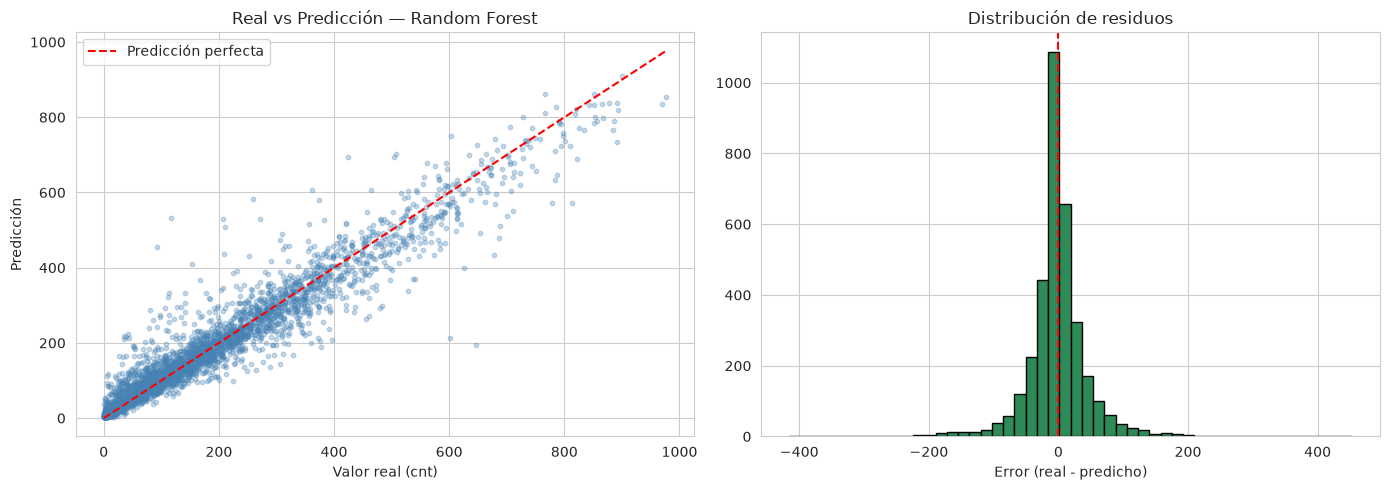

Sesgo medio de los residuos: -2.02
Desviación estándar de los residuos: 47.98
Sesgo medio cuando cnt real > 500: 36.47


In [23]:
residuos = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.3, s=10, color="steelblue")
lims = [0, max(y_test.max(), y_pred_rf.max())]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Predicción perfecta")
axes[0].set_xlabel("Valor real (cnt)")
axes[0].set_ylabel("Predicción")
axes[0].set_title("Real vs Predicción — Random Forest")
axes[0].legend()

axes[1].hist(residuos, bins=50, color="seagreen", edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribución de residuos")
axes[1].set_xlabel("Error (real - predicho)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_real_vs_prediccion.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Sesgo medio de los residuos: {residuos.mean():.2f}")
print(f"Desviación estándar de los residuos: {residuos.std():.2f}")
print(f"Sesgo medio cuando cnt real > 500: {residuos[y_test > 500].mean():.2f}")

Los puntos se agrupan alrededor de la diagonal de predicción perfecta y los residuos se distribuyen de forma aproximadamente simétrica alrededor de cero (sesgo medio de −2,02 y desviación estándar de ≈ 48 alquileres), lo que indica que el modelo no tiene un sesgo global importante. Sin embargo, en los valores altos de demanda el modelo tiende a subestimar: cuando el valor real supera los 500 alquileres, el residuo medio es de +36,5, es decir, la predicción queda en promedio ≈ 36 alquileres por debajo del valor real.

# **Análisis de sensibilidad: ¿afectó la inyección de nulos?**

Para verificar que la inyección MCAR no degrada de forma importante el desempeño, se reentrena el mismo pipeline de Random Forest sobre el dataset original sin nulos, usando la misma partición (misma semilla y mismo `test_size`), y se comparan las métricas de prueba. Se usa `clone` para crear una copia sin entrenar del modelo, de modo que `rf_model` (el modelo que se guarda más adelante) no se modifica.

In [24]:
df_limpio = pd.read_csv(DATA_RAW)
X_l = df_limpio[feature_cols].copy()
y_l = df_limpio[TARGET].copy()

X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_l, y_l, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

rf_limpio = clone(rf_model)      # copia sin entrenar; no altera rf_model
rf_limpio.fit(X_tr_l, y_tr_l)
y_pred_l = rf_limpio.predict(X_te_l)

rmse_limpio = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
r2_limpio = r2_score(y_te_l, y_pred_l)

print("=== Impacto de la inyección MCAR ===")
print(f"Con nulos inyectados : RMSE = {rmse_rf:.3f} | R² = {r2_rf:.4f}")
print(f"Con datos limpios    : RMSE = {rmse_limpio:.3f} | R² = {r2_limpio:.4f}")
print(f"Diferencia relativa en RMSE: {abs(rmse_rf - rmse_limpio) / rmse_limpio * 100:.2f}%")

=== Impacto de la inyección MCAR ===
Con nulos inyectados : RMSE = 48.017 | R² = 0.9272
Con datos limpios    : RMSE = 47.895 | R² = 0.9276
Diferencia relativa en RMSE: 0.26%


El RMSE con nulos inyectados fue de 48,02 y con el dataset limpio de 47,90 (una diferencia relativa de 0,26 %), y el R² pasó de 0,9272 a 0,9276. La diferencia es mínima, por lo que la inyección MCAR (1,2 % de nulos en `hum` y 1,7 % en `windspeed`) junto con su tratamiento mediante imputación por mediana dentro del pipeline no degradan de forma relevante el desempeño. Esto es coherente con que los nulos afectan solo a dos de las once variables predictoras y a un porcentaje pequeño de las filas.

# **Validaciones adicionales del modelo**

## **Error por segmentos**

El error global puede esconder segmentos donde el modelo falla más. Se calcula el error absoluto medio (MAE) y el sesgo (positivo = el modelo subestima, negativo = sobreestima) por hora del día, situación climática y tipo de día.

Error por hora del día:
      n    mae  sesgo
hr                   
0   152  12.57  -1.09
1   142  12.42  -4.13
2   127   9.03  -5.40
3   167   5.71  -3.00
4   129   4.78  -2.95
5   135   7.26  -4.37
6   153  17.06  -4.69
7   164  35.99  -2.02
8   142  50.80  -5.18
9   143  29.94  -2.28
10  143  26.33  -6.92
11  148  28.97   1.98
12  138  36.63   4.99
13  133  29.79   1.11
14  156  34.16   6.91
15  148  37.76  12.45
16  136  37.60   6.14
17  140  60.53 -11.75
18  154  57.47   0.17
19  143  45.64   5.53
20  150  39.86 -10.99
21  148  31.23  -8.84
22  140  28.48 -12.62
23  145  21.15  -2.47

Error por situación climática:
               n    mae  sesgo
weathersit                    
1           2298  26.52   0.40
2            889  30.08  -2.22
3            288  49.62 -20.70
4              1  12.56 -12.56

Error por tipo de día:
                            n    mae  sesgo
workingday                                 
Fin de semana / festivo  1059  34.87  -5.24
Laboral                  2417 

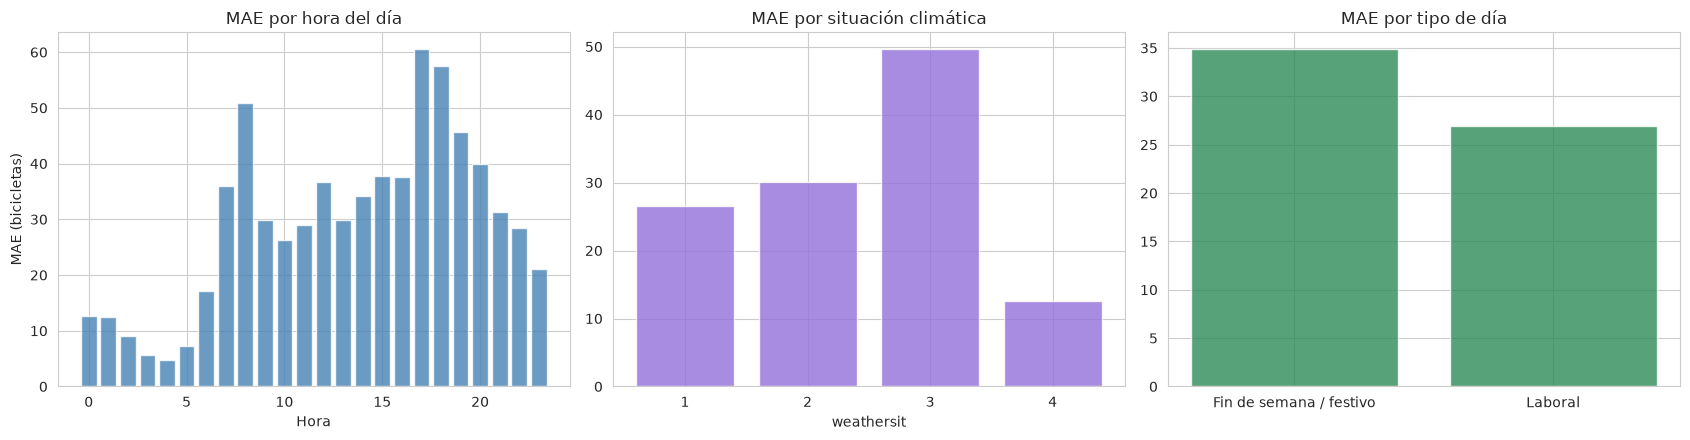

In [25]:
df_test = X_test.copy()
df_test["y_real"] = y_test.values
df_test["y_pred"] = y_pred_rf
df_test["residuo"] = df_test["y_real"] - df_test["y_pred"]
df_test["error_abs"] = df_test["residuo"].abs()

def resumen_error(columna):
    return df_test.groupby(columna).agg(
        n=("residuo", "size"),
        mae=("error_abs", "mean"),
        sesgo=("residuo", "mean"),
    ).round(2)

error_hora = resumen_error("hr")
error_clima = resumen_error("weathersit")
error_dia = resumen_error("workingday")
error_dia.index = error_dia.index.map({0: "Fin de semana / festivo", 1: "Laboral"})

print("Error por hora del día:");            print(error_hora)
print("\nError por situación climática:");   print(error_clima)
print("\nError por tipo de día:");           print(error_dia)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].bar(error_hora.index, error_hora["mae"], color="steelblue", alpha=0.8)
axes[0].set_title("MAE por hora del día")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("MAE (bicicletas)")

axes[1].bar(error_clima.index.astype(str), error_clima["mae"], color="mediumpurple", alpha=0.8)
axes[1].set_title("MAE por situación climática")
axes[1].set_xlabel("weathersit")

axes[2].bar(error_dia.index, error_dia["mae"], color="seagreen", alpha=0.8)
axes[2].set_title("MAE por tipo de día")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_error_por_segmentos.png", dpi=100, bbox_inches="tight")
plt.show()

**Por hora:** el mayor error absoluto se presenta en las horas pico (MAE ≈ 60,5 a las 17:00, ≈ 57,5 a las 18:00 y ≈ 50,8 a las 8:00), que también son las horas de mayor demanda, mientras que en la madrugada el error es bajo (menos de 6 alquileres entre las 3:00 y las 4:00).

**Por clima:** el error aumenta cuando empeora el tiempo (MAE ≈ 26,5 con cielo despejado, ≈ 30,1 con nubes o niebla y ≈ 49,6 con lluvia o nieve ligera); en esta última categoría el modelo sobreestima en promedio ≈ 20,7 alquileres. La categoría 4 solo tiene 1 registro en el conjunto de prueba, por lo que no se interpreta.

**Por tipo de día:** el modelo se equivoca más en fines de semana y festivos (MAE ≈ 34,9) que en días laborales (≈ 26,9), posiblemente porque el patrón de demanda en fin de semana es más variable que el de los desplazamientos laborales.

## **Prueba de sensibilidad a la temperatura**

Como chequeo de sensatez, se fijan todas las variables en un caso típico (día laboral de junio a las 17:00, cielo despejado) y se varía únicamente `temp` para ver cómo responde la predicción.

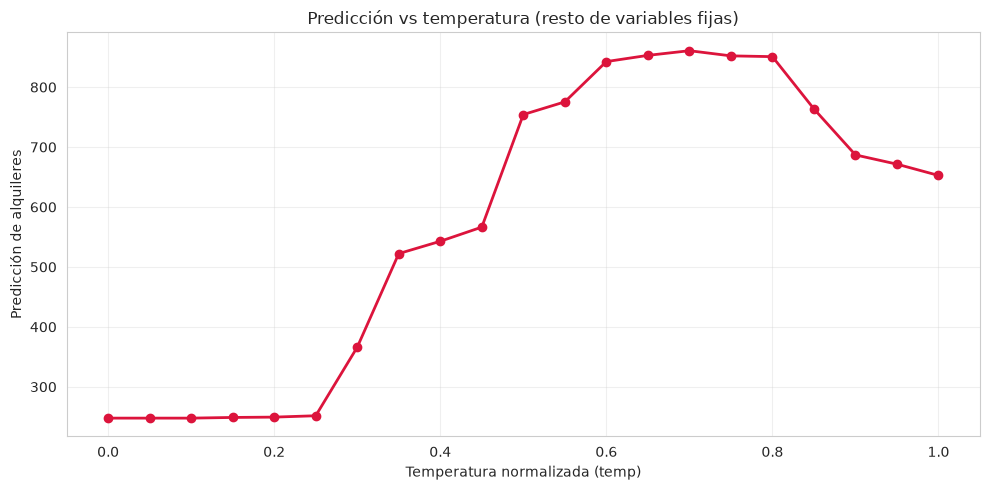

Predicción con temp=0.00: 248 | temp=0.50: 754 | temp=1.00: 653


In [26]:
temp_range = np.linspace(0.0, 1.0, 21)
caso_base = {
    "season": 3, "yr": 1, "mnth": 6, "hr": 17, "holiday": 0, "weekday": 3,
    "workingday": 1, "weathersit": 1, "hum": 0.5, "windspeed": 0.2,
}
X_prueba = pd.DataFrame([{**caso_base, "temp": t} for t in temp_range])[feature_cols]
pred_temp = rf_model.predict(X_prueba)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(temp_range, pred_temp, marker="o", color="crimson", linewidth=2)
ax.set_xlabel("Temperatura normalizada (temp)")
ax.set_ylabel("Predicción de alquileres")
ax.set_title("Predicción vs temperatura (resto de variables fijas)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_sensibilidad_temperatura.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Predicción con temp=0.00: {pred_temp[0]:.0f} | temp=0.50: {pred_temp[10]:.0f} | temp=1.00: {pred_temp[-1]:.0f}")

La predicción es casi constante (≈ 248 alquileres) para temperaturas bajas, crece con fuerza entre `temp` = 0,25 y 0,70 (hasta ≈ 861) y luego disminuye con temperaturas muy altas (≈ 653 con `temp` = 1,0). Es un comportamiento coherente con lo visto en el EDA: más temperatura implica más demanda hasta cierto punto, y el calor extremo la reduce.

Hay dos limitaciones que conviene tener presentes y son que: el Random Forest produce una respuesta escalonada y no una curva suave, y en el dataset los días laborales de junio a las 17:00 solo tienen temperaturas entre 0,60 y 0,98, por lo que las predicciones para valores más bajos son una extrapolación de combinaciones que casi no existen en los datos y no deben interpretarse literalmente.

# **Guardado del modelo, persistencia y métricas**

In [27]:
model_path = MODELS_DIR / "model_v1.joblib"
joblib.dump(rf_model, model_path, compress=3)
print(f"Modelo guardado en: {model_path}")
print(f"Tamaño del archivo: {model_path.stat().st_size / 1e6:.1f} MB")

metricas = {
    "modelo": "RandomForestRegressor",
    "hiperparametros": {
        "n_estimators": rf_model.named_steps["model"].n_estimators,
        "random_state": RANDOM_STATE,
    },
    "baseline_ridge": {
        "mae": float(mae_baseline),
        "rmse": float(rmse_baseline),
        "r2": float(r2_baseline),
    },
    "test": {
        "mae": float(mae_rf),
        "rmse": float(rmse_rf),
        "r2": float(r2_rf),
    },
    "sensibilidad_nulos": {
        "rmse_con_nulos": float(rmse_rf),
        "rmse_sin_nulos": float(rmse_limpio),
        "r2_con_nulos": float(r2_rf),
        "r2_sin_nulos": float(r2_limpio),
        "diff_relativa_rmse_pct": float(abs(rmse_rf - rmse_limpio) / rmse_limpio * 100),
    },
    "features": feature_cols,
    "random_state": RANDOM_STATE,
}

metrics_path = REPORTS_DIR / "metricas_v1.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)

print(f"Métricas guardadas en: {metrics_path}")

Modelo guardado en: /home/santiago/GitHub/modelos1-price-prediction/fase-1/models/model_v1.joblib
Tamaño del archivo: 41.8 MB
Métricas guardadas en: /home/santiago/GitHub/modelos1-price-prediction/fase-1/reports/metricas_v1.json


# **Verificación de carga del modelo y generación de predicciones**

In [28]:
modelo_cargado = joblib.load(model_path)
print(f"Modelo cargado correctamente: {type(modelo_cargado).__name__}")

pred_cargado = modelo_cargado.predict(X_test)
print(f"Predicciones idénticas al modelo en memoria: {np.allclose(pred_cargado, y_pred_rf)}")

# 1. Train vs test (verificación de sobreajuste)
pred_train = modelo_cargado.predict(X_train)
print("\nDesempeño del modelo cargado:")
for nombre, y_real, y_est in [("Train", y_train, pred_train), ("Test", y_test, pred_cargado)]:
    print(f"  {nombre:5} -> MAE {mean_absolute_error(y_real, y_est):6.2f} | "
          f"RMSE {np.sqrt(mean_squared_error(y_real, y_est)):6.2f} | R² {r2_score(y_real, y_est):.4f}")

# 2. Un registro con valores faltantes: el pipeline debería imputarlos por sí solo
registro = X_test.iloc[[0]].copy()
registro[["hum", "windspeed"]] = np.nan
print(f"\nPredicción con hum y windspeed nulos: {modelo_cargado.predict(registro)[0]:.1f}")

# 3. Un conteo de alquileres no puede ser negativo
print(f"Predicciones negativas en test: {(pred_cargado < 0).sum()}")

# 4. Ejemplo con 5 registros del conjunto de prueba
ejemplo = pd.DataFrame({
    "cnt_real": y_test.head(5).values,
    "cnt_predicho": modelo_cargado.predict(X_test.head(5)).round(1)
})
display(ejemplo)

Modelo cargado correctamente: Pipeline
Predicciones idénticas al modelo en memoria: True

Desempeño del modelo cargado:
  Train -> MAE  11.30 | RMSE  18.33 | R² 0.9899
  Test  -> MAE  29.34 | RMSE  48.02 | R² 0.9272

Predicción con hum y windspeed nulos: 380.9
Predicciones negativas en test: 0


,cnt_real,cnt_predicho
0,425,392.8
1,88,123.5
2,4,13.6
3,526,552.0
4,13,17.9


El modelo cargado desde el archivo `.joblib` produce exactamente las mismas predicciones que el modelo en memoria, lo que demuestra que el guardado y la carga funcionan correctamente. Además, el R² en entrenamiento (0,9899) es mayor que el de prueba (0,9272); esta brecha es habitual en un Random Forest (sobreajuste moderado) y el desempeño en prueba sigue siendo alto. El pipeline guardado también imputa por sí solo los valores faltantes de un registro nuevo (`hum` y `windspeed` nulos) y no genera predicciones negativas.

# **Conclusiones**

## **Principales dificultades encontradas**

Una de las principales dificultades fue el tratamiento de los valores faltantes. El dataset original no contenía valores nulos, por lo que se realizó una inyección controlada de valores faltantes mediante un mecanismo MCAR. Se introdujeron valores nulos de manera aleatoria en las variables hum y windspeed, utilizando porcentajes definidos previamente. Posteriormente, estos valores son tratados mediante imputación con la mediana dentro del pipeline de preprocesamiento.

Otra dificultad fue evitar la fuga de información al seleccionar las variables predictoras. Las variables casual y registered fueron excluidas debido a que forman parte directamente del cálculo de cnt, por lo que utilizarlas como variables predictoras permitiría proporcionar al modelo información directamente relacionada con el valor que se intenta predecir.

Finalmente, fue necesario integrar en un mismo pipeline el tratamiento de variables numéricas y categóricas. Las variables numéricas reciben imputación y escalamiento, mientras que las variables categóricas son procesadas mediante One-Hot Encoding. Esto permite mantener un proceso de transformación consistente entre los datos utilizados para entrenar y evaluar los modelos.

## **Aspectos a mejorar en futuras versiones**

- **Optimización de hiperparámetros:** ajustar el Random Forest con técnicas como GridSearchCV o RandomizedSearchCV y compararlo con otros algoritmos de regresión, como Gradient Boosting Regressor.
- **Validación agrupada por día:** como cada día aparece hasta 24 veces, una partición o validación cruzada agrupada por fecha (por ejemplo con GroupShuffleSplit o GroupKFold) daría una estimación menos optimista del desempeño en días nuevos.
- **Reducir el error en los segmentos más difíciles:** horas pico (17:00, 18:00 y 8:00), clima adverso y fines de semana, donde se observaron los mayores errores; además, el modelo subestima los valores altos de demanda.
- **Reducir el sobreajuste** (R² de 0,99 en entrenamiento frente a 0,93 en prueba) limitando la profundidad de los árboles o ajustando `min_samples_leaf`.
- **Codificación cíclica** de `hr`, `mnth` y `weekday` (seno/coseno) como alternativa al one-hot, y creación de variables derivadas (por ejemplo, hora pico o interacciones entre hora y tipo de día).
- **Incorporar factores externos**, como eventos especiales, mencionados como limitación del dataset.